In [1]:
import os
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import binomtest
import matplotlib.ticker as plticker

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['savefig.dpi'] = 600

In [2]:
data_folder = '../Results/burst_modeling/statistical_analysis_proper'

In [3]:
df_S1 = pd.read_csv(os.path.join(data_folder, 'S1', 'S1_results.csv'))
df_S2 = pd.read_csv(os.path.join(data_folder, 'S2', 'S2_results.csv'))
df_S3 = pd.read_csv(os.path.join(data_folder, 'S3', 'S3_results.csv'))
df_S4 = pd.read_csv(os.path.join(data_folder, 'S4', 'S4_results.csv'))
df_S5 = pd.read_csv(os.path.join(data_folder, 'S5', 'S5_results.csv'))

df_all = pd.concat([df_S1, df_S2, df_S3, df_S4, df_S5], ignore_index=True)
df_all = df_all.rename({'div_offset' : 'div_pos'}, axis='columns')

df_all = df_all[['subject', 'fold', 'opt_params', 'div_steep', 'div_pos',
                 'ecavs', 'lcavs', 'eclvs', 'lclvs', 'train_loss', 'test_loss']]

subj_fold_col = df_all['subject']+'_f'+df_all['fold'].astype('string')
df_all.insert(2, 'subj_fold', subj_fold_col)
df_all = df_all.round(3)

In [4]:
df_pivot = df_all.pivot(
    index=['subject', 'fold'],
    columns='opt_params',
    values='test_loss'
).reset_index()

df_pivot.columns.name = None

In [5]:
mean_row = {col: None for col in df_pivot.columns}
mean_row['subject'] = 'mean'
mean_row['fold'] = '------------'
mean_row[0] = df_pivot[0].mean()
mean_row[2] = df_pivot[2].mean()
mean_row[4] = df_pivot[4].mean()
mean_row[6] = df_pivot[6].mean()

In [6]:
total_row = {col: None for col in df_pivot.columns}
total_row['subject'] = 'total'
total_row['fold'] = 'better'
total_row[0] = np.nan
total_row[2] = (df_pivot[2] < df_pivot[0]).sum()
total_row[4] = (df_pivot[4] < df_pivot[2]).sum()
total_row[6] = (df_pivot[6] < df_pivot[4]).sum()

In [7]:
rows_n = len(df_pivot)

p_binom_row = {col: None for col in df_pivot.columns}
p_binom_row['subject'] = 'p-val'
p_binom_row['fold'] = 'binomial'
p_binom_row[0] = np.nan
p_binom_row[2] = binomtest(total_row[2], rows_n, p=0.5, alternative="two-sided").pvalue
p_binom_row[4] = binomtest(total_row[4], rows_n, p=0.5, alternative="two-sided").pvalue
p_binom_row[6] = binomtest(total_row[6], rows_n, p=0.5, alternative="two-sided").pvalue

In [8]:
p_wilcox_row = {col: None for col in df_pivot.columns}
p_wilcox_row['subject'] = 'p-val'
p_wilcox_row['fold'] = 'Wilcoxon'
p_wilcox_row[0] = np.nan
p_wilcox_row[2] = pg.wilcoxon(df_pivot[2], df_pivot[0], alternative='less')['p-val'].values[0]
p_wilcox_row[4] = pg.wilcoxon(df_pivot[4], df_pivot[2], alternative='less')['p-val'].values[0]
p_wilcox_row[6] = pg.wilcoxon(df_pivot[6], df_pivot[4], alternative='less')['p-val'].values[0]

In [9]:
def highlight_opt_params_diff(s):

    styles = ["" for _ in s.index]

    # Check if this is the TOTAL row
    if s['subject'] == 'total' or (s['subject'] == 'p-val' and s['fold'] == 'binomial'):
        for i in [2,4,6]:
            if(p_binom_row[i] < 0.05):
                styles[s.index.get_loc(i)] = "background-color: green"
            else:
                styles[s.index.get_loc(i)] = "background-color: red"
    elif (s['subject'] == 'p-val' and s['fold'] == 'Wilcoxon'):
        for i in [2,4,6]:
            if(p_wilcox_row[i] < 0.05):
                styles[s.index.get_loc(i)] = "background-color: green"
            else:
                styles[s.index.get_loc(i)] = "background-color: red"
    else:

        if(s['subject'] == 'mean'):
                color_red = "background-color: red"
                color_green = "background-color: green"
        else:
                color_red = "background-color: darkred"
                color_green = "background-color: darkgreen"  
          
        if s[2] < s[0]:
            styles[s.index.get_loc(2)] = color_green
        else:
            styles[s.index.get_loc(2)] = color_red

        if s[4] < s[2]:
            styles[s.index.get_loc(4)] = color_green
        else:
            styles[s.index.get_loc(4)] = color_red

        if s[6] < s[4]:
            styles[s.index.get_loc(6)] = color_green
        else:
            styles[s.index.get_loc(6)] = color_red

    return styles

In [10]:
df_pivot_res = pd.concat([df_pivot, pd.DataFrame([mean_row]), pd.DataFrame([total_row]),
                          pd.DataFrame([p_binom_row]), pd.DataFrame([p_wilcox_row])], ignore_index=True)
df_pivot_res.style.apply(highlight_opt_params_diff,
                         axis=1).format({0: '{:.3f}', 2: '{:.3f}', 4: '{:.3f}', 6: '{:.3f}'})

,subject,fold,0,2,4,6
0,S1,0,2.485,0.452,0.114,0.122
1,S1,1,2.651,0.282,0.130,0.120
2,S1,2,2.573,0.258,0.093,0.091
3,S1,3,2.502,0.300,0.086,0.083
4,S1,4,2.577,0.348,0.070,0.068
5,S1,5,2.572,0.323,0.102,0.095
6,S1,6,2.451,0.361,0.127,0.120
7,S1,7,2.735,0.347,0.104,0.113
8,S1,8,2.594,0.349,0.124,0.122
9,S1,9,2.540,0.307,0.121,0.109


In [11]:
# test for normality of the folds differences
# if p > 0.05 we assume the distribution is normal

print('%f' % shapiro(df_pivot[0] - df_pivot[2]).pvalue)
print('%f' % shapiro(df_pivot[2] - df_pivot[4]).pvalue)
print('%f' % shapiro(df_pivot[4] - df_pivot[6]).pvalue)

0.000893
0.022355
0.000000


In [12]:
df_pivot_mean = df_pivot.groupby('subject').mean().reset_index().drop('fold', axis=1)

mean_row_mean = df_pivot[[0, 2, 4, 6]].mean().to_frame().T
mean_row_mean['subject'] = 'mean'
df_pivot_mean2 = pd.concat([df_pivot_mean, mean_row_mean], ignore_index=True)

df_pivot_mean2.style.apply(highlight_opt_params_diff, axis=1).format(
    {0: '{:.3f}', 2: '{:.3f}', 4: '{:.3f}', 6: '{:.3f}'})

,subject,0,2,4,6
0,S1,2.568,0.333,0.107,0.104
1,S2,1.541,0.470,0.273,0.277
2,S3,1.556,0.483,0.409,0.436
3,S4,1.880,0.381,0.256,0.279
4,S5,1.449,0.464,0.265,0.289
5,mean,1.799,0.426,0.262,0.277


In [13]:
# Wilcoxon signed-rank test

print(pg.wilcoxon(df_pivot_mean[2], df_pivot_mean[0], alternative='less').round(6))
print(pg.wilcoxon(df_pivot_mean[4], df_pivot_mean[2], alternative='less').round(6))
print(pg.wilcoxon(df_pivot_mean[6], df_pivot_mean[4], alternative='less').round(6))

          W-val alternative    p-val  RBC  CLES
Wilcoxon    0.0        less  0.03125 -1.0   1.0
          W-val alternative    p-val  RBC  CLES
Wilcoxon    0.0        less  0.03125 -1.0  0.92
          W-val alternative    p-val       RBC  CLES
Wilcoxon   14.0        less  0.96875  0.866667  0.32


In [14]:
# test for normality of the folds differences
# if p > 0.05 we assume the distribution is normal

print('%f' % shapiro(df_pivot_mean[0] - df_pivot_mean[2]).pvalue)
print('%f' % shapiro(df_pivot_mean[2] - df_pivot_mean[4]).pvalue)
print('%f' % shapiro(df_pivot_mean[4] - df_pivot_mean[6]).pvalue)

0.080747
0.375448
0.137066


In [15]:
# T-test for pairs

print(pg.ttest(df_pivot_mean[2], df_pivot_mean[0], paired=True, alternative='less')['p-val'].round(6))
print(pg.ttest(df_pivot_mean[4], df_pivot_mean[2], paired=True, alternative='less')['p-val'].round(6))
print(pg.ttest(df_pivot_mean[6], df_pivot_mean[4], paired=True, alternative='less')['p-val'].round(6))

T-test    0.002092
Name: p-val, dtype: float64
T-test    0.002171
Name: p-val, dtype: float64
T-test    0.967536
Name: p-val, dtype: float64


In [16]:
# Observed variability explanation [%]
# static burst model -> 0% of variability explained
# loss = 0 -> 100% of variability explained

df_pivot_mean_expl = df_pivot_mean2.copy()

df_pivot_mean_expl[6] /= df_pivot_mean_expl[0]
df_pivot_mean_expl[4] /= df_pivot_mean_expl[0]
df_pivot_mean_expl[2] /= df_pivot_mean_expl[0]
df_pivot_mean_expl[0] /= df_pivot_mean_expl[0]

df_pivot_mean_expl[6] = (1-df_pivot_mean_expl[6])*100
df_pivot_mean_expl[4] = (1-df_pivot_mean_expl[4])*100
df_pivot_mean_expl[2] = (1-df_pivot_mean_expl[2])*100
df_pivot_mean_expl[0] = (1-df_pivot_mean_expl[0])*100

df_pivot_mean_expl.style.format({0: '{:.3f}', 2: '{:.3f}', 4: '{:.3f}', 6: '{:.3f}'})

,subject,0,2,4,6
0,S1,0.000,87.044,95.829,95.938
1,S2,0.000,69.493,82.288,82.002
2,S3,0.000,68.978,73.683,71.954
3,S4,0.000,79.714,86.368,85.134
4,S5,0.000,67.987,81.737,80.026
5,mean,0.000,76.309,85.429,84.579


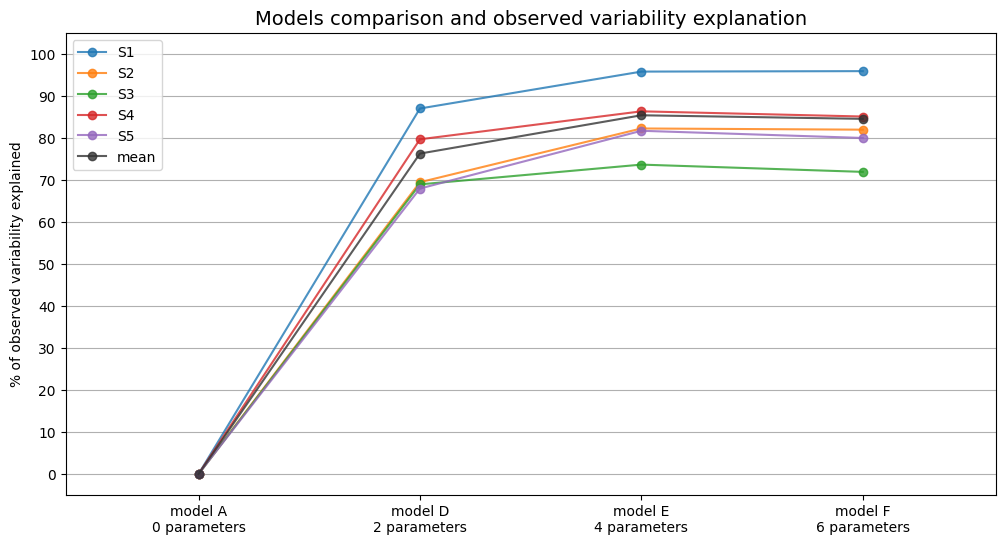

In [17]:
fig, axs = plt.subplots()
plt.title('Models comparison and observed variability explanation', fontsize=14)
x_labels = ['model A\n0 parameters', 'model D\n2 parameters', 'model E\n4 parameters', 'model F\n6 parameters']

for i in range(len(df_pivot_mean_expl)):
    y_values_test = df_pivot_mean_expl.iloc[i][[0,2,4,6]]
    subj_i = df_pivot_mean_expl['subject'][i]
    if(subj_i == 'mean'):
        axs.plot(x_labels, y_values_test , 'o-', label=subj_i, c='0.2', alpha=0.8)
    else:
        axs.plot(x_labels, y_values_test , 'o-', label=subj_i, alpha=0.8)

axs.grid(axis='y')
axs.margins(x=0.2)
axs.legend(loc='upper left')
axs.yaxis.set_major_locator(plticker.MultipleLocator(10))
axs.set_ylim(-5, 105)
axs.set_ylabel('% of observed variability explained')
plt.savefig(os.path.join(data_folder, 'variability explanation'), bbox_inches='tight')

In [18]:
# div_steep - division curve steepness
# div_pos - division curve center position
# ecavs - earlier component amplitude variability scaler
# lcavs - later component amplitude variability scaler
# eclvs - earlier component latency variability scaler
# lclvs - later component latency variability scaler

pd.set_option('display.max_rows', 20)
df_opt_6 = df_all[df_all['opt_params']==6]
df_opt_6.round(3)

,subject,fold,subj_fold,opt_params,div_steep,div_pos,ecavs,lcavs,eclvs,lclvs,train_loss,test_loss
3,S1,0,S1_f0,6,2.082,0.344,0.123,0.528,2.050,2.787,0.069,0.122
7,S1,1,S1_f1,6,1.811,0.345,0.201,0.512,1.342,2.776,0.103,0.120
11,S1,2,S1_f2,6,1.663,0.336,0.171,0.524,1.731,2.828,0.065,0.091
15,S1,3,S1_f3,6,1.620,0.324,0.000,0.500,1.238,2.812,0.087,0.083
19,S1,4,S1_f4,6,2.059,0.336,0.290,0.527,1.646,2.724,0.079,0.068
...,...,...,...,...,...,...,...,...,...,...,...,...
183,S5,5,S5_f5,6,0.500,0.622,0.293,1.880,0.732,4.480,0.189,0.376
187,S5,6,S5_f6,6,0.500,0.412,0.187,0.588,0.665,2.177,0.157,0.307
191,S5,7,S5_f7,6,0.500,0.500,0.241,1.037,1.302,3.313,0.192,0.428
195,S5,8,S5_f8,6,0.500,0.466,0.267,0.753,0.910,2.557,0.165,0.185


In [19]:
print(pg.wilcoxon(df_opt_6['ecavs'], df_opt_6['lcavs']).round(6))
print(pg.wilcoxon(df_opt_6['eclvs'], df_opt_6['lclvs']).round(6))

          W-val alternative  p-val  RBC    CLES
Wilcoxon    0.0   two-sided    0.0 -1.0  0.0396
          W-val alternative  p-val      RBC    CLES
Wilcoxon    7.0   two-sided    0.0 -0.98902  0.1042


In [20]:
df_opt_6 = df_all[df_all['opt_params']==6]

mean_row_6 = df_opt_6.drop(['subject', 'fold', 'subj_fold', 'opt_params'], axis=1).mean().to_frame().T
mean_row_6['subject'] = 'mean'

df_opt_6_mean = df_opt_6.drop(['subj_fold', 'fold', 'opt_params'], axis=1).groupby('subject').mean().reset_index()
df_opt_6_mean2 = pd.concat([df_opt_6_mean, mean_row_6], ignore_index=True)

df_opt_6_mean2.round(3)

,subject,div_steep,div_pos,ecavs,lcavs,eclvs,lclvs,train_loss,test_loss
0,S1,1.923,0.339,0.134,0.520,1.563,2.763,0.082,0.104
1,S2,3.589,0.342,0.036,0.253,0.529,1.393,0.192,0.277
2,S3,0.808,0.514,0.093,0.586,1.348,2.169,0.210,0.436
3,S4,1.566,0.524,0.137,0.617,1.512,2.830,0.185,0.279
4,S5,0.509,0.462,0.158,0.932,0.862,2.819,0.155,0.290
5,mean,1.679,0.436,0.112,0.582,1.163,2.395,0.165,0.277


In [21]:
# test for normality of the folds differences
# if p > 0.05 we assume the distribution is normal

print('%f' % shapiro(df_opt_6_mean['lcavs'] - df_opt_6_mean['ecavs']).pvalue)
print('%f' % shapiro(df_opt_6_mean['lclvs'] - df_opt_6_mean['eclvs']).pvalue)

0.775121
0.366132


In [22]:
# T-test for pairs

print(pg.ttest(df_opt_6_mean['lcavs'], df_opt_6_mean['ecavs'], paired=True, alternative='greater')['p-val'].round(6))
print(pg.ttest(df_opt_6_mean['lclvs'], df_opt_6_mean['eclvs'], paired=True, alternative='greater')['p-val'].round(6))

T-test    0.003285
Name: p-val, dtype: float64
T-test    0.001914
Name: p-val, dtype: float64


In [23]:
df_opt_4 = df_all[df_all['opt_params']==4]

mean_row_4 = df_opt_4.drop(['subject', 'fold', 'subj_fold', 'opt_params'], axis=1).mean().to_frame().T
mean_row_4['subject'] = 'mean'

df_opt_4_mean = df_opt_4.drop(['subj_fold', 'fold', 'opt_params'], axis=1).groupby('subject').mean().reset_index()
df_opt_4_mean2 = pd.concat([df_opt_4_mean, mean_row_4], ignore_index=True)

df_opt_4_mean2[['ecavs', 'eclvs']] = '-----'
df_opt_4_mean2.round(3)

,subject,div_steep,div_pos,ecavs,lcavs,eclvs,lclvs,train_loss,test_loss
0,S1,1.394,0.322,-----,0.519,-----,2.777,0.088,0.107
1,S2,2.163,0.326,-----,0.252,-----,1.396,0.198,0.273
2,S3,0.640,0.385,-----,0.366,-----,2.031,0.265,0.410
3,S4,0.546,0.368,-----,0.492,-----,2.236,0.211,0.256
4,S5,0.510,0.402,-----,0.667,-----,2.354,0.172,0.265
5,mean,1.050,0.361,-----,0.459,-----,2.159,0.187,0.262


In [24]:
df_opt_6 = df_all[df_all['opt_params']==6]
mean_row_6 = df_opt_6.drop(['subject', 'fold', 'subj_fold'], axis=1).mean().to_frame().T.round(3)
mean_row_6['opt_params'] = 6

df_opt_4 = df_all[df_all['opt_params']==4]
mean_row_4 = df_opt_4.drop(['subject', 'fold', 'subj_fold'], axis=1).mean().to_frame().T.round(3)
mean_row_4[['ecavs', 'eclvs']] = '-----'
mean_row_4['opt_params'] = 4

df_opt_2 = df_all[df_all['opt_params']==2]
mean_row_2 = df_opt_2.drop(['subject', 'fold', 'subj_fold'], axis=1).mean().to_frame().T.round(3)
mean_row_2['opt_params'] = 2
mean_row_2[['div_steep', 'div_pos', 'ecavs', 'eclvs']] = '-----'

df_opt_0 = df_all[df_all['opt_params']==0]
mean_row_0 = df_opt_0.drop(['subject', 'fold', 'subj_fold'], axis=1).mean().to_frame().T.round(3)
mean_row_0[['div_steep', 'div_pos', 'ecavs', 'lcavs', 'eclvs', 'lclvs']] = '-----'
mean_row_0['opt_params'] = 0

In [25]:
pd.concat([mean_row_0, mean_row_2, mean_row_4, mean_row_6], ignore_index=True)

,opt_params,div_steep,div_pos,ecavs,lcavs,eclvs,lclvs,train_loss,test_loss
0,0,-----,-----,-----,-----,-----,-----,1.799,1.799
1,2,-----,-----,-----,0.318,-----,1.614,0.379,0.426
2,4,1.05,0.361,-----,0.459,-----,2.159,0.187,0.262
3,6,1.679,0.436,0.112,0.582,1.163,2.395,0.165,0.277
